验证所有数据归一化(在剩余总额中的比例)后是否符合理论上的均匀分布

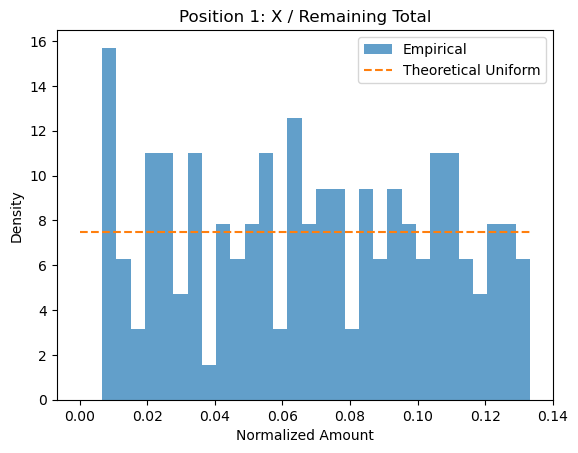

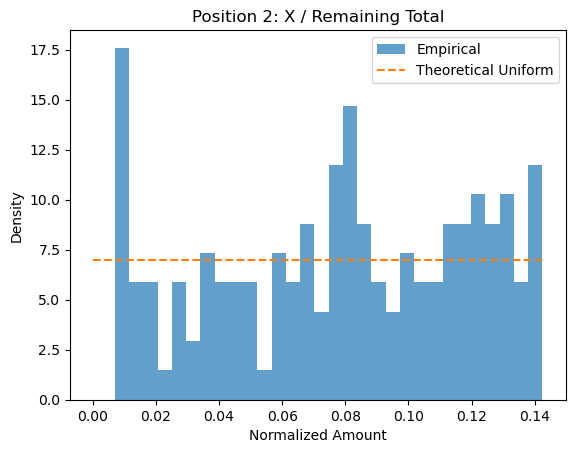

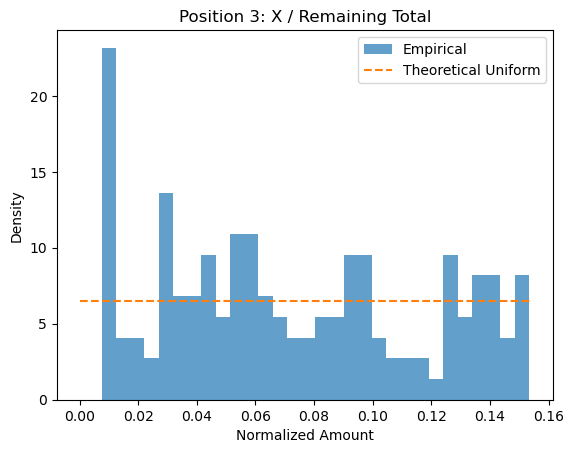

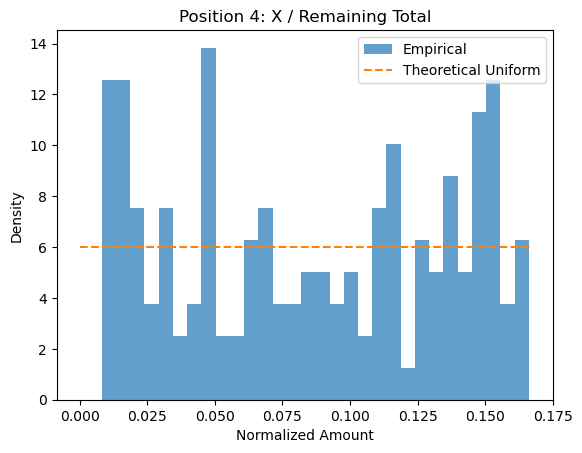

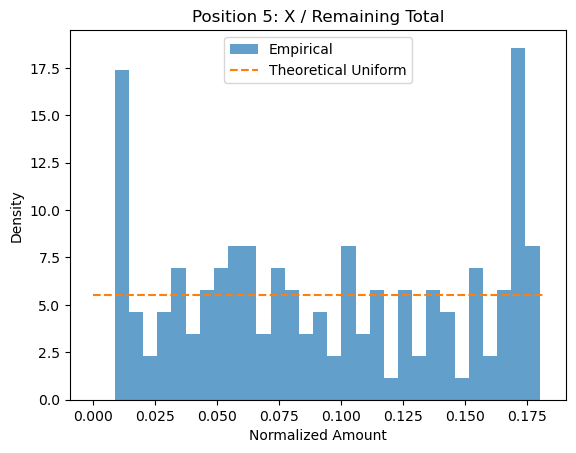

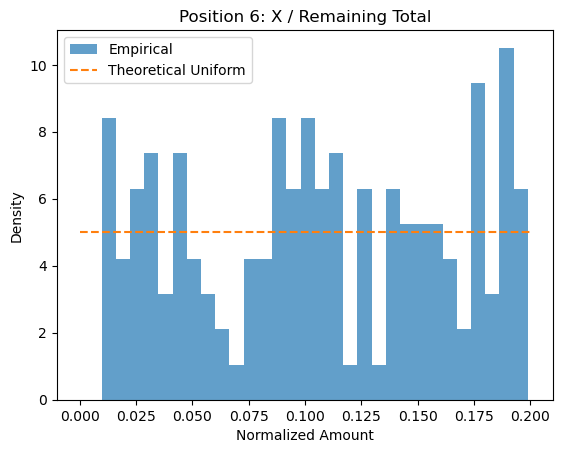

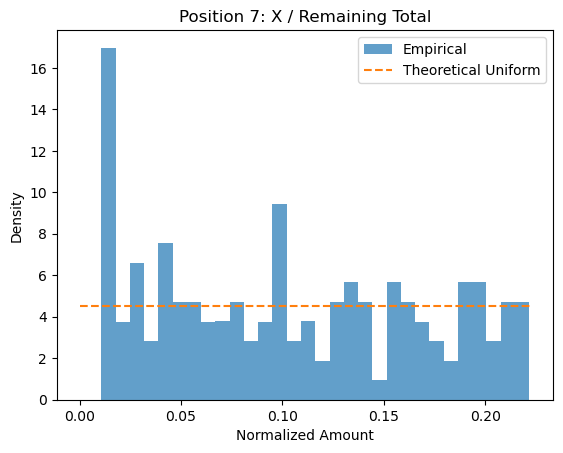

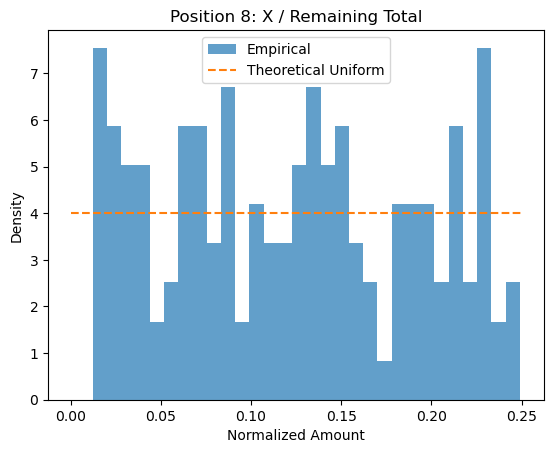

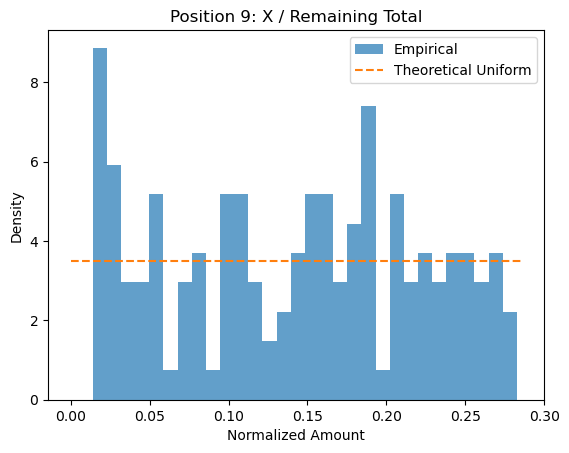

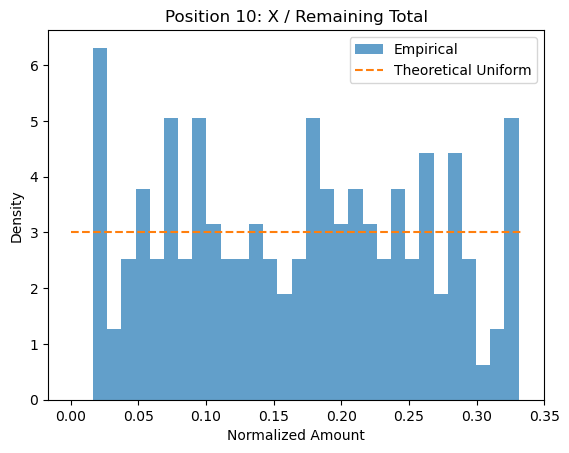

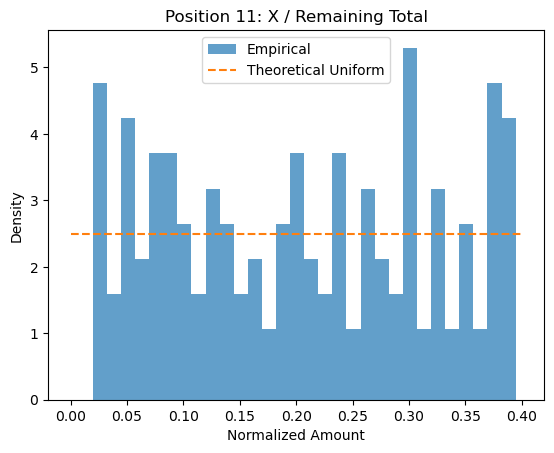

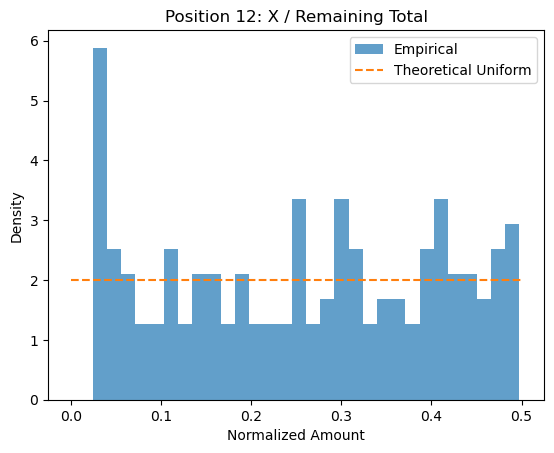

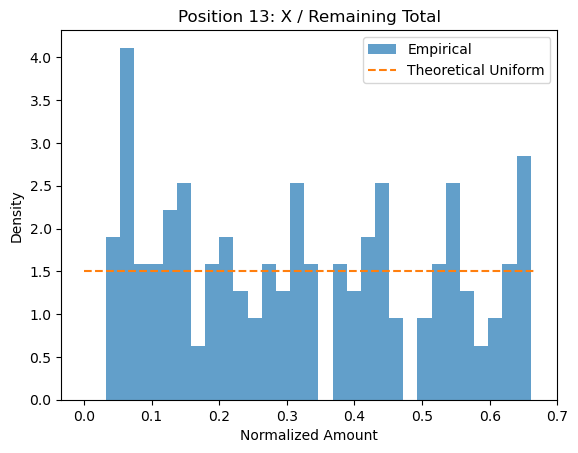

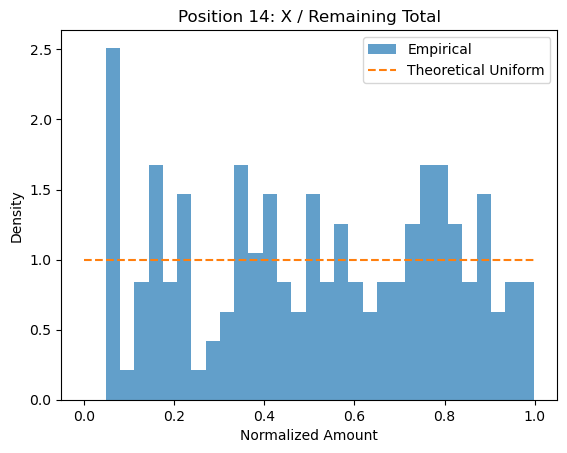

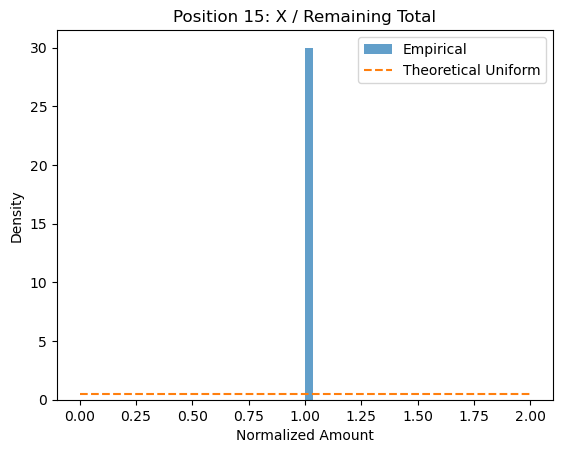

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =====================
# 1. 读取数据
# =====================
# 假设:
# 行 = 实验次数
# 列 = 位次 (第1个抢到的人, 第2个, ...)
df = pd.read_csv("15peoplerealdata1.csv")

# Skip the 'Trial' column (first column)
df_data = df.iloc[:, 1:]

num_positions = df_data.shape[1]

# =====================
# 2. 计算归一化比例
# =====================
ratios = {}

for i, col in enumerate(df_data.columns):
    # 剩余总额（包含自己）
    remaining_sum = df_data.iloc[:, i:].sum(axis=1)
    ratios[col] = df_data[col] / remaining_sum

ratio_df = pd.DataFrame(ratios)

# =====================
# 3. 绘制直方图验证均匀分布
# =====================
for i, col in enumerate(ratio_df.columns):
    plt.figure()
    plt.hist(
        ratio_df[col],
        bins=30,
        density=True,
        alpha=0.7,
        label="Empirical"
    )

    # 理论均匀分布上界
    upper = 2 / (num_positions - i)

    x = np.linspace(0, upper, 200)
    y = np.ones_like(x) / upper
    plt.plot(x, y, linestyle="--", label="Theoretical Uniform")

    plt.title(f"Position {i+1}: X / Remaining Total")
    plt.xlabel("Normalized Amount")
    plt.ylabel("Density")
    plt.legend()
    plt.show()

K-S检验

In [37]:
from scipy.stats import kstest

print("Kolmogorov–Smirnov Test Results")
print("-" * 50)

for i, col in enumerate(ratio_df.columns):
    # 理论均匀分布的上界
    upper = 2 / (num_positions - i)

    # 经验样本
    data = ratio_df[col].dropna().values

    # KS 检验
    # H0: data ~ Uniform(0, upper)
    ks_stat, p_value = kstest(
        data,
        'uniform',
        args=(0, upper)
    )

    print(
        f"Position {i+1:2d} | "
        f"KS statistic = {ks_stat:.4f} | "
        f"p-value = {p_value:.4f}"
    )


Kolmogorov–Smirnov Test Results
--------------------------------------------------
Position  1 | KS statistic = 0.0501 | p-value = 0.8239
Position  2 | KS statistic = 0.1158 | p-value = 0.0321
Position  3 | KS statistic = 0.0922 | p-value = 0.1445
Position  4 | KS statistic = 0.0733 | p-value = 0.3735
Position  5 | KS statistic = 0.0881 | p-value = 0.1805
Position  6 | KS statistic = 0.0797 | p-value = 0.2784
Position  7 | KS statistic = 0.0750 | p-value = 0.3467
Position  8 | KS statistic = 0.0590 | p-value = 0.6465
Position  9 | KS statistic = 0.0489 | p-value = 0.8452
Position 10 | KS statistic = 0.0493 | p-value = 0.8377
Position 11 | KS statistic = 0.0490 | p-value = 0.8435
Position 12 | KS statistic = 0.0518 | p-value = 0.7932
Position 13 | KS statistic = 0.0592 | p-value = 0.6433
Position 14 | KS statistic = 0.0569 | p-value = 0.6903
Position 15 | KS statistic = 0.5000 | p-value = 0.0000


第二个人抢到金额的实际分布：

[4.61 2.09 6.38 6.54 2.46 3.48 4.69 6.3  1.45 7.35 2.18 4.84 0.84 7.19
 5.44 6.02 1.69 6.43 0.4  6.62 4.55 5.15 8.34 0.77 6.56 8.16 6.76 7.19
 6.66 1.97 7.67 4.76 1.99 5.27 7.19 7.29 2.61 4.63 7.89 6.89 0.53 5.56
 1.4  2.59 1.06 1.58 0.58 1.32 4.   3.5  5.7  4.1  2.34 5.2  5.88 1.02
 1.02 3.61 3.47 3.7  4.43 4.52 0.4  1.52 3.65 7.5  2.55 4.14 7.75 3.6
 7.01 5.59 6.9  6.3  2.12 6.55 2.66 2.51 5.2  6.86 5.19 6.27 2.65 3.79
 8.24 5.33 4.06 4.28 6.28 4.21 4.44 2.39 6.67 0.4  6.42 0.72 0.39 4.41
 6.49 8.29 6.73 3.95 5.74 4.46 6.72 7.19 7.29 0.42 3.68 4.36 3.51 2.58
 0.37 4.92 2.22 3.76 0.39 4.51 3.41 2.71 5.14 3.69 4.86 7.73 6.6  3.61
 0.39 1.94 6.08 0.78 6.72 7.94 0.38 7.19 6.35 7.97 7.   4.27 0.55 5.14
 4.83 6.8  4.91 3.58 3.   5.81 5.   5.26 8.13 0.84]
Total amount m = 62.0
Participant Number n= 15
Max empirical X2 = 8.34
Theoretical upper bound = 8.857142857142858


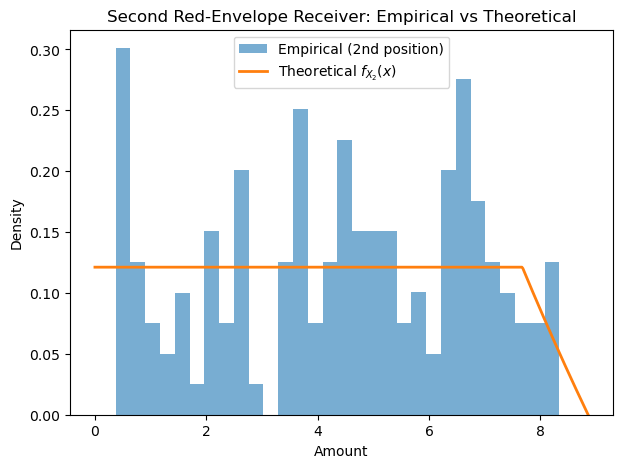

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# =====================
# 基本参数
# =====================
# 第二个抢红包的数据
x2_data = df.iloc[:-1, 2].values
print(x2_data)

n = df.shape[1]-1                      # 人数
m = df.sum(axis=1, numeric_only=True).iloc[1]  # 总金额（从第一行取得）
print("Total amount m =", m)
print("Participant Number n=", n)
print("Max empirical X2 =", x2_data.max())
print("Theoretical upper bound =", 2 * m / (n - 1))


# =====================
# 理论 PDF 定义
# =====================
def f_X2(x, n, m):
    x = np.asarray(x)
    pdf = np.zeros_like(x, dtype=float)

    a = 2 * m * (n - 2) / (n * (n - 1))
    b = 2 * m / (n - 1)
    c = n * (n - 1) / (4 * m)

    mask1 = (x >= 0) & (x <= a)
    pdf[mask1] = c * np.log(n / (n - 2))

    mask2 = (x > a) & (x <= b)
    pdf[mask2] = c * np.log((2 * m) / ((n - 1) * x[mask2]) )

    return pdf

# =====================
# 作图：经验直方图 + 理论曲线
# =====================
x_grid = np.linspace(0, 2 * m / (n - 1), 500)
pdf_vals = f_X2(x_grid, n, m)

plt.figure(figsize=(7,5))
plt.hist(
    x2_data,
    bins=30,
    density=True,
    alpha=0.6,
    label="Empirical (2nd position)"
)

plt.plot(
    x_grid,
    pdf_vals,
    linewidth=2,
    label=r"Theoretical $f_{X_2}(x)$"
)

plt.xlabel("Amount")
plt.ylabel("Density")
plt.title("Second Red-Envelope Receiver: Empirical vs Theoretical")
plt.legend()
plt.show()